# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [29]:
import os

import pylab as pl
from lightning_fabric.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import sys
sys.path.append('../../lesson3/seminar')
from lesson3.seminar.wine_quality_data import WineQualityDataModule
from lesson3.seminar.lightning_module import BaseLightningModule
from lesson3.seminar.utils import set_seed
from pytorch_lightning import Trainer
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
set_seed(42)
import torch
torch.cuda.is_available(), torch.version.cuda, torch.version.git_version
max_epochs = 20

## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [30]:
# Загружаем данные
dm = WineQualityDataModule(batch_size=128)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

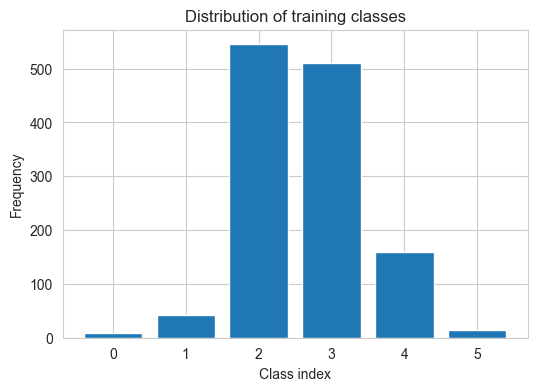

Class weights: [26.64583333  5.07539683  0.3911315   0.41797386  1.34067086 14.21111111]


In [31]:

train_labels = []
for i in range(len(dm.train_dataset)):
    _, yi = dm.train_dataset[i]
    train_labels.append(int(yi))
train_labels = np.array(train_labels)


plt.figure(figsize=(6, 4))
plt.hist(train_labels, bins=np.arange(dm.n_classes + 1) - 0.5, rwidth=0.8)
plt.xticks(range(dm.n_classes))
plt.xlabel('Class index')
plt.ylabel('Frequency')
plt.title('Distribution of training classes')
plt.show()


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(dm.n_classes),
    y=train_labels
)

print(f'Class weights: {class_weights}')


## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [32]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim
    
    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)
        
        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim
    
    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor
        
        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim
    
    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        
        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2

        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)
    
    def forward(self, x):
        identity = x
        
        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)
        
        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [33]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.
    
    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        # Входная проекция
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # Три ветви: Bottleneck, Inverted Bottleneck и Regular
        self.bottleneck_branch = nn.ModuleList([
            BottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])
        self.inverted_branch = nn.ModuleList([
            InvertedBottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])
        self.regular_branch = nn.ModuleList([
            RegularBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)
        ])

        # Выходная проекция.  Для concat вход равен hidden_dim*3, для sum — hidden_dim
        combined_dim = hidden_dim * 3 if combine_mode == 'concat' else hidden_dim
        self.output_proj = nn.Linear(combined_dim, output_dim)

    def forward(self, x):
        # Входная проекция
        x = self.input_proj(x)
        # Bottleneck ветка
        out_bottleneck = x
        for block in self.bottleneck_branch:
            out_bottleneck = block(out_bottleneck)
        # Inverted Bottleneck ветка
        out_inverted = x
        for block in self.inverted_branch:
            out_inverted = block(out_inverted)
        # Regular ветка
        out_regular = x
        for block in self.regular_branch:
            out_regular = block(out_regular)
        # Объединение результатов
        if self.combine_mode == 'concat':
            out = torch.cat([out_bottleneck, out_inverted, out_regular], dim=-1)
        else:
            out = out_bottleneck + out_inverted + out_regular
        # Выходная проекция
        logits = self.output_proj(out)
        return logits

print('Multi-Branch модель определена!')

Multi-Branch модель определена!


## 4. Код обучение

## 5. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [34]:
from pytorch_lightning.profilers import SimpleProfiler


def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=max_epochs,
    lr=1e-3,
    optimizer_type='adam'
):
    """
    Обучает модель с weighted loss.

    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')

    Returns:
        dict с метриками
    """
    # TODO: Создайте loss function
    # Если class_weights не None, используйте nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    # Иначе используйте обычный nn.CrossEntropyLoss()
    if class_weights is not None:
        weight_tensor = torch.tensor(class_weights, dtype=torch.float32)
        loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
    else:
        loss_fn = nn.CrossEntropyLoss()

    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )
    checkpoint_callback = ModelCheckpoint(
        monitor='val_f1_macro',
        mode='max',
        save_top_k=1,
        filename='best-{epoch:02d}-{val_f1:.4f}',
        dirpath='./checkpoints',
    )

    early_stopping = EarlyStopping(
        monitor='val_f1_macro',
        patience=5,
        mode='max',
    )

    # Profiler
    profiler = SimpleProfiler(dirpath='./profiler', filename='baseline_profile')
    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        callbacks=[checkpoint_callback, early_stopping],
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=False
    )
    trainer.fit(lightning_model, dm)

    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item()
    }

In [ ]:
# TODO: Обучите итоговую модель с лучшими гиперпараметрами

hidden_dims = [64, 128, 256]
depths = [2, 4, 6, 8]
lrs = [1e-3]
optimizers = ['adamw']
combine_modes=['concat']
dropouts = [0.25,0.5,0.1]
best_val_f1 = 0.0
best_config = None
max_epochs = 50

# Подберём гиперпараметры методом простого перебора
# Best configuration: hidden_dim=256, num_blocks=2, lr=0.001, opt=adamw, val_f1=0.3419
# === Итоговые результаты ===
# F1 score: 0.3762
# Accuracy: 0.5813

for hd in hidden_dims:
    for nb in depths:
        for lr in lrs:
            for opt in optimizers:
                for combine_mode in combine_modes:
                    for dropout in dropouts:
                         model = MultiBranchMLP(
                             input_dim=dm.input_dim,
                             hidden_dim=hd,
                             output_dim=dm.n_classes,
                             num_blocks=nb,
                             dropout=dropout,
                             combine_mode=combine_mode
                         )
                         metrics = train_model(
                             model,
                             dm,
                             class_weights=class_weights,
                             max_epochs=max_epochs,
                             lr=lr,
                             optimizer_type=opt
                         )
                         val_f1 = metrics['val_f1']
                         val_acc = metrics['val_acc']
                         print(f'hidden_dim={hd}, num_blocks={nb}, lr={lr}, opt={opt} -> val_f1={val_f1:.4f}, val_acc={val_acc:.4f}')
                         if val_f1 > best_val_f1:
                             best_val_f1 = val_f1
                             best_config = (hd, nb, lr, opt,combine_mode,dropout)

best_hidden_dim, best_depth, best_lr, best_optimizer,best_combine_mode,best_dropout = best_config
print(f'Best configuration: hidden_dim={best_hidden_dim}, num_blocks={best_depth}, lr={best_lr}, opt={best_optimizer}, val_f1={best_val_f1:.4f}, best_combine_mode={best_combine_mode}  best_dropout={best_dropout}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: accuracy=0.2500, f1_macro=0.1333


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Epoch 23: accuracy=0.4107, f1_macro=0.2544


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 24: accuracy=0.4107, f1_macro=0.2560


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 25: accuracy=0.4145, f1_macro=0.2585


In [36]:

# final_model = MultiBranchMLP(
#     input_dim=dm.input_dim,
#     hidden_dim=best_hidden_dim,
#     output_dim=dm.n_classes,
#     num_blocks=best_depth,
#     dropout=0.1,
#     combine_mode=best_combine_mode
# )
#
# final_results = train_model(
#     final_model,
#     dm,
#     class_weights=class_weights,
#     max_epochs=100,
#     lr=best_lr,
#     optimizer_type=best_optimizer
# )

# print(f'=== Итоговые результаты ===')
# print(f"F1 score: {final_results['val_f1']:.4f}")
# print(f"Accuracy: {final_results['val_acc']:.4f}")

print(f'Best configuration: hidden_dim={best_hidden_dim}, num_blocks={best_depth}, lr={best_lr}, opt={best_optimizer}, val_f1={best_val_f1:.4f}, best_combine_mode={best_combine_mode}')


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: accuracy=0.1797, f1_macro=0.1061


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 98: accuracy=0.5286, f1_macro=0.3298


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: accuracy=0.5295, f1_macro=0.3304
=== Итоговые результаты ===
F1 score: 0.3304
Accuracy: 0.5295
Best configuration: hidden_dim=256, num_blocks=2, lr=0.001, opt=adamw, val_f1=0.3274, best_combine_mode=concat
